# Trading Workshop 2

Agenda:
- How do you implement a trading strategy?
- How do you backtest it?
- How do you optimize some of its parameters?

This notebook is self-contained: the price/volume datasets it uses are stored in the `data/` folder of this repository, so no external account or upload step is required.

The strategy can be extended to other assets simply by using `yfinance`.
(One caveat: Yahoo Finance limits how much data you can download per request and how many requests you can make. For instance, you cannot download more than 60 days of 15-minute data in a single request.)

Free alternatives for richer datasets:
- Manually download data from [Dukascopy](https://www.dukascopy.com/trading-tools/widgets/quotes/historical_data_feed)
- Open a Paper Trading account with Interactive Brokers and use their API (more involved, but lets you automate larger downloads)
- Plenty of other options (free or paid market data subscriptions)

Here is the plan we'll follow to build our strategy:
- Download price time series
- Process the data and add indicators
- Define signals and use them to trigger orders
- Implement the strategy itself
- Backtest it
- Optimize its parameters

In [1]:
# If a package is missing (e.g. on Google Colab), uncomment the line below:
# %pip install -r requirements.txt

# Downloading the data (as in the first workshop)

In [2]:
import pandas as pd
import yfinance as yf

The helper below shows how you would pull fresh data from Yahoo Finance for any ticker/timeframe. It asks for input interactively, so it is left un-run here. The rest of the notebook uses the CSV files already saved in `data/`.

```python
def download_data_yfinance():
    ticker_symbol = input("Enter the ticker symbol: ")
    timeframe = input("Enter the timeframe: ")
    start_date = input("Enter the start date (YYYY-MM-DD): ")
    end_date = input("Enter the end date (YYYY-MM-DD): ")

    ticker = yf.Ticker(ticker_symbol)

    df = ticker.history(start=start_date, end=end_date, interval=timeframe)
    df.drop(columns=["Dividends", "Stock Splits"], inplace=True)
    df.index = df.index.tz_convert('Europe/Paris')
    df.to_csv(f"data/{ticker_symbol.upper()}_{timeframe.upper()}_{start_date}_{end_date}.csv")

    print("Data downloaded successfully in the data folder.")

download_data_yfinance()

# example ticker symbols: AAPL, MSFT, NVDA, TSLA, AMZN, GOOGL, META ...
# example timeframes: 1m, 5m, 15m, 30m, 1h, 1d
# example start_date / end_date: 2025-02-01
```

In [3]:
df = pd.read_csv("data/MSFT_15M_2025-02-01_2025-02-10.csv")
pd.set_option('display.max_columns', None)
print(df.info())
print(df.head())
print(len(df))

<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Datetime  130 non-null    str    
 1   Open      130 non-null    float64
 2   High      130 non-null    float64
 3   Low       130 non-null    float64
 4   Close     130 non-null    float64
 5   Volume    130 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 6.2 KB
None
                    Datetime        Open        High         Low       Close  \
0  2025-02-03 15:30:00+01:00  411.760010  414.720001  409.119995  412.750000   
1  2025-02-03 15:45:00+01:00  412.859985  412.859985  411.250092  411.369995   
2  2025-02-03 16:00:00+01:00  411.250000  411.420013  409.130005  409.250000   
3  2025-02-03 16:15:00+01:00  409.220001  411.970001  408.670013  411.674988   
4  2025-02-03 16:30:00+01:00  411.649994  413.299988  411.109985  413.200012   

    Volume  
0  3731594  
1  1046842  
2  1213578  

We get a file with `Datetime` as the first column and OHLC (Open - High - Low - Close) prices for the next four columns, and finally the last column represents the Volume (number of shares traded during the timeframe between two datetimes).

# First strategy implementation

## Strategy 1: Scalping Bollinger Strategy (Timeframe: 5 minutes)

### How does the strategy work?

- **Several indicators:**
    - **EMA**: two exponential moving averages used to generate a signal (one over 30 periods, the other over 50).
    - **ATR**: average candle size, used to compute the stop loss and take profit.
    - **Bollinger Bands**: used to build the second signal (over 15 candles).

- **Signals:**
    - We put `0` in the dataframe when there is no signal, `1` for a sell signal, and `2` for a buy signal.
    - If over the last 7 candles:
    \begin{equation}
       EMA_{fast} < EMA_{slow}
    \end{equation}
      then we set `1` (bearish).
      If over the last 7 candles:
      $$ EMA_{fast} > EMA_{slow} $$
      then we set `2` (bullish).
      Otherwise, `0`.
    - If the deviation from the 15-period simple moving average (SMA) is greater than $1.5\sigma$, a signal is generated using the Bollinger Bands.
    - The final signal used to trigger orders is the **intersection of the two signals above**.

- **Trade management:**
    - Only one trade at a time (we make sure the previous position is closed before opening a new one).
    - A stop loss and a take profit are set as soon as a position is opened, based on:
      - $TPSL$
      - $SL_{coef}$

In [4]:
### Imports ###
import os
import pandas as pd
import pandas_ta as ta
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import datetime

# backtesting.py auto-detects Jupyter on import (via the JPY_PARENT_PID and
# MPLBACKEND environment variables) and sets up a Bokeh notebook output
# (a warning plus a "Loading BokehJS..." banner) in case Backtest.plot() gets
# called. We only use its static, Plotly-rendered plots here, so we hide both
# markers for this one import to skip that unused setup.
_env_backup = {k: os.environ.pop(k, None) for k in ("JPY_PARENT_PID", "MPLBACKEND")}
import backtesting.backtesting as _backtesting_internals
from backtesting import Strategy, Backtest
for _k, _v in _env_backup.items():
    if _v is not None:
        os.environ[_k] = _v

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
# Static (PNG) rendering keeps the charts visible both in Jupyter and on GitHub.
pio.renderers.default = "png"

# Backtest.run() reports its progress with a tqdm widget by default. That is
# useful while a run is in progress, but it leaves dead, unusable widget
# state baked into the saved notebook once execution is done, so we turn it
# off here.
_backtesting_internals._tqdm = lambda seq, **kwargs: seq


In [5]:
### Loading the data, adding indicators, cleaning up ###
df = pd.read_csv("data/META_5M_2025-01-01_2025-02-10.csv")

df = df[df['Volume'] != 0]  # dropping rows with zero volume
df.reset_index(drop=True, inplace=True)
df["EMA_slow"] = ta.ema(df.Close, length=50)  # exponential moving average, 50 periods
df["EMA_fast"] = ta.ema(df.Close, length=30)  # exponential moving average, 30 periods
df['RSI'] = ta.rsi(df.Close, length=10)       # RSI indicator, 10 periods
my_bbands = ta.bbands(df.Close, length=15, lower_std=1.5, upper_std=1.5)    # Bollinger Bands
df['ATR'] = ta.atr(df.High, df.Low, df.Close, length=7)  # Average True Range, 7 periods
df = df.join(my_bbands, how='left')           # adding the Bollinger Bands to the dataframe
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

df.head()

,Datetime,Open,High,Low,Close,Volume,EMA_slow,EMA_fast,RSI,ATR,BBL_15_1.5_1.5,BBM_15_1.5_1.5,BBU_15_1.5_1.5,BBB_15_1.5_1.5,BBP_15_1.5_1.5
0,2025-01-02 19:35:00+01:00,590.599976,592.190002,590.109985,591.489990,56130,596.386158,594.167291,42.774226,2.108282,589.418355,591.674748,593.931141,0.762714,0.459059
1,2025-01-02 19:40:00+01:00,591.549988,593.229980,590.964111,593.229980,62108,596.262387,594.106820,50.212080,2.130795,589.646781,591.555078,593.463376,0.645180,0.938847
2,2025-01-02 19:45:00+01:00,593.000000,593.593994,592.030029,592.409973,82290,596.111312,593.997346,47.012467,2.049819,589.810904,591.439742,593.068580,0.550804,0.797829
3,2025-01-02 19:50:00+01:00,592.710022,592.760010,591.289978,591.525024,50060,595.931457,593.837841,43.675264,1.966992,589.795466,591.410079,593.024692,0.546022,0.535595
4,2025-01-02 19:55:00+01:00,591.599976,593.659973,591.599976,593.659973,65810,595.842380,593.826366,52.679480,1.990986,589.758138,591.582886,593.407634,0.616904,1.069144


In [6]:
# Buy/sell signal definitions

### EMA signal (Exponential Moving Average) ###

def ema_signal(df, current_candle, backcandles):
    start = max(0, current_candle - backcandles)
    end = current_candle
    relevant_rows = df.iloc[start:end]
    if all(relevant_rows["EMA_fast"] < relevant_rows["EMA_slow"]):
        return 1                        # sell signal (1 = sell, 2 = buy)
    elif all(relevant_rows["EMA_fast"] > relevant_rows["EMA_slow"]):
        return 2
    else:
        return 0

def total_signal(df, current_candle, backcandles):
    if (ema_signal(df, current_candle, backcandles) == 2
        and df.Close[current_candle] <= df['BBL_15_1.5_1.5'][current_candle]
        #and df.RSI[current_candle]<60
        ):
            return 2
    if (ema_signal(df, current_candle, backcandles) == 1
        and df.Close[current_candle] >= df['BBU_15_1.5_1.5'][current_candle]
        #and df.RSI[current_candle]>40
        ):

            return 1
    return 0

def pointpos(x):        # for displaying trade entries on the chart
    if x['TotalSignal'] == 1:
        return x['High'] * 1.01
    elif x['TotalSignal'] == 2:
        return x['Low'] * 0.99
    else:
        return 0

def SIGNAL():
    return df['TotalSignal']

# Adding the signals to the dataframe

df['EMASignal'] = df.apply(lambda row: ema_signal(df, row.name, 7), axis=1)
df['TotalSignal'] = df.apply(lambda row: total_signal(df, row.name, 7), axis=1)
df['pointpos'] = df.apply(pointpos, axis=1)

df.head()

,Datetime,Open,High,Low,Close,Volume,EMA_slow,EMA_fast,RSI,ATR,BBL_15_1.5_1.5,BBM_15_1.5_1.5,BBU_15_1.5_1.5,BBB_15_1.5_1.5,BBP_15_1.5_1.5,EMASignal,TotalSignal,pointpos
0,2025-01-02 19:35:00+01:00,590.599976,592.190002,590.109985,591.489990,56130,596.386158,594.167291,42.774226,2.108282,589.418355,591.674748,593.931141,0.762714,0.459059,1,0,0.000000
1,2025-01-02 19:40:00+01:00,591.549988,593.229980,590.964111,593.229980,62108,596.262387,594.106820,50.212080,2.130795,589.646781,591.555078,593.463376,0.645180,0.938847,1,0,0.000000
2,2025-01-02 19:45:00+01:00,593.000000,593.593994,592.030029,592.409973,82290,596.111312,593.997346,47.012467,2.049819,589.810904,591.439742,593.068580,0.550804,0.797829,1,0,0.000000
3,2025-01-02 19:50:00+01:00,592.710022,592.760010,591.289978,591.525024,50060,595.931457,593.837841,43.675264,1.966992,589.795466,591.410079,593.024692,0.546022,0.535595,1,0,0.000000
4,2025-01-02 19:55:00+01:00,591.599976,593.659973,591.599976,593.659973,65810,595.842380,593.826366,52.679480,1.990986,589.758138,591.582886,593.407634,0.616904,1.069144,1,1,599.596573


In [7]:
### Strategy definition ###

class ScalpingBollinger_5min(Strategy):
    initsize = 1
    mysize = initsize
    slcoef = 2.1
    TPSLRatio = 2.5
    def init(self):
        super().init()
        self.signal1 = self.I(SIGNAL)
        #df['RSI']=ta.rsi(df.Close, length=self.rsi_length)

    def next(self):
        super().next()
        slatr = self.slcoef*self.data.ATR[-1]
        TPSLRatio = self.TPSLRatio

        # if len(self.trades)>0:                Close trades when the market is overbought/oversold
        #     if self.trades[-1].is_long and self.data.RSI[-1]>=90:
        #         self.trades[-1].close()
        #     elif self.trades[-1].is_short and self.data.RSI[-1]<=10:
        #         self.trades[-1].close()

        if self.signal1==2 and len(self.trades)==0:
            sl1 = self.data.Close[-1] - slatr
            tp1 = self.data.Close[-1] + slatr*TPSLRatio
            self.buy(sl=sl1, tp=tp1, size=self.mysize)

        elif self.signal1==1 and len(self.trades)==0:
            sl1 = self.data.Close[-1] + slatr
            tp1 = self.data.Close[-1] - slatr*TPSLRatio
            self.sell(sl=sl1, tp=tp1, size=self.mysize)

# Backtesting

In [8]:
def plot_signals(df, last_n=300):
    # Only showing the last `last_n` candles so the static image stays readable.
    df = df.tail(last_n)
    fig = go.Figure(data=[go.Candlestick(x=df.index,
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'],
                name="price"),

                go.Scatter(x=df.index, y=df['BBL_15_1.5_1.5'],
                           line=dict(color='green', width=1),
                           name="BBL"),
                go.Scatter(x=df.index, y=df['BBU_15_1.5_1.5'],
                           line=dict(color='green', width=1),
                           name="BBU"),
                go.Scatter(x=df.index, y=df['EMA_fast'],
                           line=dict(color='black', width=1),
                           name="EMA_fast"),
                go.Scatter(x=df.index, y=df['EMA_slow'],
                           line=dict(color='blue', width=1),
                           name="EMA_slow")])
    df_filtered = df[df["pointpos"]!=0]
    fig.add_scatter(x=df_filtered.index, y=df_filtered["pointpos"], mode="markers",
                marker=dict(size=5, color="MediumPurple"),
                name="entry")
    fig.update_layout(title='Price, indicators and entry signals (last %d candles)' % last_n,
                       xaxis_rangeslider_visible=False, height=500)
    fig.show()

def SIGNAL():
    return df['TotalSignal']

def run_strategy(df,strategy,cash=100,margin=1/50,commission=.00):
    bt = Backtest(df, strategy, cash=cash, margin=margin, commission=commission)
    stat = bt.run()
    print(stat)

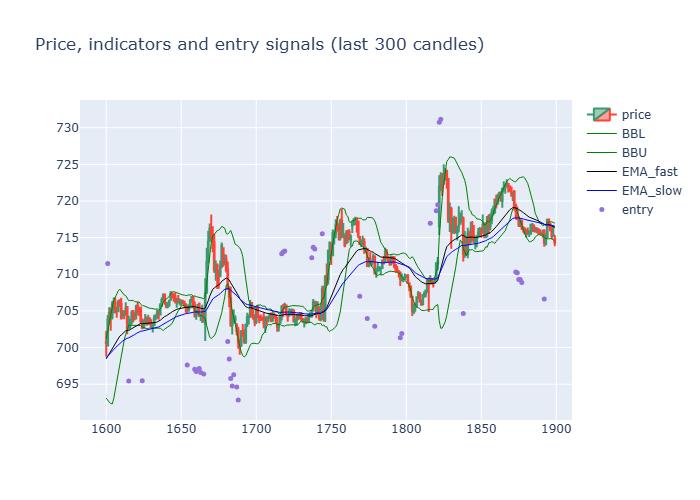

In [9]:
plot_signals(df)

In [10]:
run_strategy(df, ScalpingBollinger_5min, cash=100, margin=1/10, commission=.00)

Start                                       0
End                                      1899
Duration                                 1899
Exposure Time [%]                    74.57895
Equity Final [$]                    172.81062
Equity Peak [$]                     180.49257
Return [%]                           72.81062
Buy & Hold Return [%]                20.75606
Return (Ann.) [%]                         0.0
Volatility (Ann.) [%]                      --
Sharpe Ratio                               --
Sortino Ratio                              --
Calmar Ratio                              0.0
Alpha [%]                            47.29488
Beta                                  1.22932
Max. Drawdown [%]                   -32.89383
Avg. Drawdown [%]                    -4.79646
Max. Drawdown Duration                  553.0
Avg. Drawdown Duration               48.10811
# Trades                                   41
Win Rate [%]                         31.70732
Best Trade [%]                    

C:\Users\theop\AppData\Local\Temp\ipykernel_45164\3438983426.py:35: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(df, strategy, cash=cash, margin=margin, commission=commission)
C:\Users\theop\AppData\Local\Temp\ipykernel_45164\3438983426.py:35: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(df, strategy, cash=cash, margin=margin, commission=commission)
C:\Users\theop\AppData\Local\Temp\ipykernel_45164\3438983426.py:36: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stat = bt.run()


# Optimizing the strategy's parameters

We grid-search the two parameters ourselves with a plain double loop over `bt.run(...)` (rather than `Backtest.optimize`, whose multiprocess grid search is flaky on Windows) and plot the resulting return heatmap.

C:\Users\theop\AppData\Local\Temp\ipykernel_45164\941774202.py:3: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(df, strategy, cash=cash, margin=margin, commission=commission)
C:\Users\theop\AppData\Local\Temp\ipykernel_45164\941774202.py:3: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(df, strategy, cash=cash, margin=margin, commission=commission)


C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1185: Broker canceled the order due to insufficient margin (equity=64.14, margin_available=64.14).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1253: Broker canceled the order due to insufficient margin (equity=64.14, margin_available=64.14).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1266: Broker canceled the order due to insufficient margin (equity=64.14, margin_available=64.14).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: Us

C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1278: Broker canceled the order due to insufficient margin (equity=65.09, margin_available=65.09).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1279: Broker canceled the order due to insufficient margin (equity=65.09, margin_available=65.09).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1280: Broker canceled the order due to insufficient margin (equity=65.09, margin_available=65.09).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: Us

C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1121: Broker canceled the order due to insufficient margin (equity=63.03, margin_available=63.03).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1122: Broker canceled the order due to insufficient margin (equity=63.03, margin_available=63.03).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1132: Broker canceled the order due to insufficient margin (equity=63.03, margin_available=63.03).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: Us

C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1278: Broker canceled the order due to insufficient margin (equity=66.39, margin_available=66.39).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1279: Broker canceled the order due to insufficient margin (equity=66.39, margin_available=66.39).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1280: Broker canceled the order due to insufficient margin (equity=66.39, margin_available=66.39).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: Us

...

C:\Users\theop\AppData\Local\Temp\ipykernel_45164\941774202.py:8: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run(**{p1: v1, p2: v2})
C:\Users\theop\AppData\Local\Temp\ipykernel_45164\941774202.py:8: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run(**{p1: v1, p2: v2})
C:\Users\theop\AppData\Local\Temp\ipykernel_45164\941774202.py:8: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run(**{p1: v1, p2: v2})
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=548: Broker canceled the order due to insufficient margin (equity=58.24, margin_available=58

C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1823: Broker canceled the order due to insufficient margin (equity=67.08, margin_available=67.08).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1824: Broker canceled the order due to insufficient margin (equity=67.08, margin_available=67.08).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1839: Broker canceled the order due to insufficient margin (equity=67.08, margin_available=67.08).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: Us

C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=540: Broker canceled the order due to insufficient margin (equity=57.26, margin_available=57.26).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=541: Broker canceled the order due to insufficient margin (equity=57.26, margin_available=57.26).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=543: Broker canceled the order due to insufficient margin (equity=57.26, margin_available=57.26).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserW

C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1874: Broker canceled the order due to insufficient margin (equity=54.16, margin_available=54.16).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1875: Broker canceled the order due to insufficient margin (equity=54.16, margin_available=54.16).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=1876: Broker canceled the order due to insufficient margin (equity=54.16, margin_available=54.16).
  warnings.warn(
C:\Users\theop\Documents\Telecom_Paris\important\repo_projets_github\Portfolio_Optimization\.venv\Lib\site-packages\backtesting\backtesting.py:1009: Us

Best parameters: slcoef=1.8, TPSLRatio=3.0, Return [%]=120.31


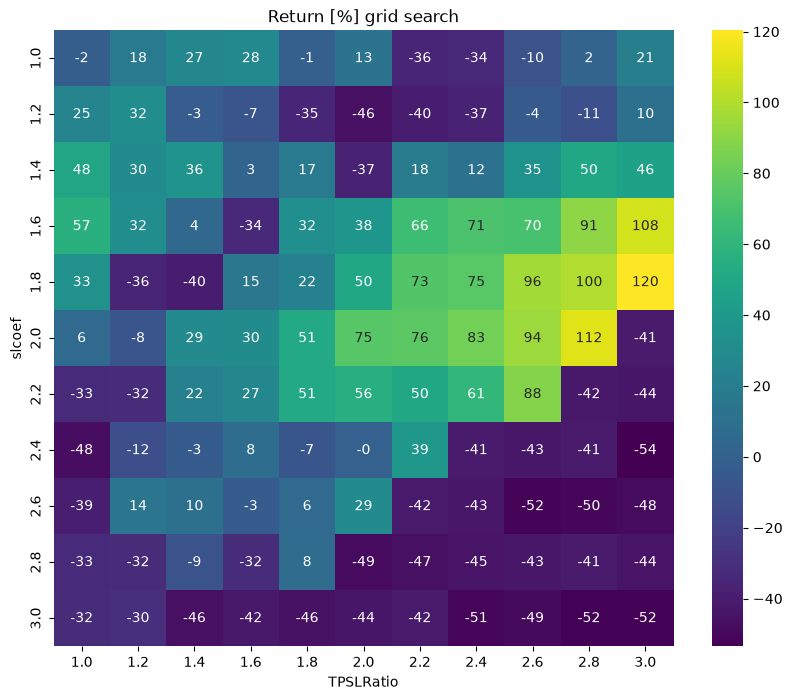

,1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.4,2.6,2.8,3.0
1.0,-2.160660,17.501434,27.212694,27.996860,-1.283240,12.823485,-35.863271,-33.540653,-9.804655,1.552335,20.537134
1.2,24.929444,31.945428,-3.125277,-7.398901,-34.907465,-46.123804,-39.542422,-37.033078,-4.008288,-11.030581,9.847327
1.4,48.410061,29.690333,35.764662,2.737933,17.133024,-36.965513,18.102233,11.517545,35.230981,50.111378,45.651125
1.6,56.580368,31.845785,4.350125,-33.613693,32.439083,38.020822,65.638244,70.975552,69.834010,90.748892,108.159017
1.8,33.485774,-36.086793,-40.220686,15.118165,22.098477,50.267176,72.824462,74.910013,96.488175,99.860035,120.310052
2.0,5.889218,-7.794237,29.098639,30.247549,51.415522,74.661653,76.381611,83.416650,94.165497,111.580827,-40.786438
2.2,-32.940591,-32.119365,21.822118,27.008279,51.128247,55.778544,50.268744,61.173139,87.794590,-42.064411,-43.619586
2.4,-47.639402,-11.677640,-3.288037,7.956559,-6.965205,-0.434776,39.323081,-41.193684,-42.904788,-41.257073,-53.529341
2.6,-39.060778,14.071666,9.936974,-3.451816,5.765508,28.720807,-41.762628,-42.804001,-52.112562,-50.327537,-48.442802
2.8,-32.916686,-31.867086,-9.070595,-31.955542,7.510262,-48.508298,-46.585964,-44.663629,-42.741295,-40.780560,-44.028217


In [11]:
def optimize_strategy(df, strategy, param_grid, cash=100, margin=1/10, commission=.00):
    # param_grid: dict of exactly two {param_name: list_of_values}, used as the heatmap's axes.
    bt = Backtest(df, strategy, cash=cash, margin=margin, commission=commission)
    (p1, values1), (p2, values2) = param_grid.items()
    results = pd.DataFrame(index=values1, columns=values2, dtype=float)
    for v1 in values1:
        for v2 in values2:
            stats = bt.run(**{p1: v1, p2: v2})
            results.loc[v1, v2] = stats['Return [%]']

    best_v1, best_v2 = results.stack().idxmax()
    print(f"Best parameters: {p1}={best_v1}, {p2}={best_v2}, Return [%]={results.loc[best_v1, best_v2]:.2f}")

    plt.figure(figsize=(10, 8))
    sns.heatmap(results, cmap='viridis', annot=True, fmt=".0f")
    plt.xlabel(p2)
    plt.ylabel(p1)
    plt.title('Return [%] grid search')
    plt.show()
    return results

optimize_strategy(
    df, ScalpingBollinger_5min,
    {'slcoef': [i/10 for i in range(10, 31, 2)], 'TPSLRatio': [i/10 for i in range(10, 31, 2)]},
    cash=100, margin=1/10, commission=.00,
)

# Your turn: build your own strategy!

Below is a full worked example built with the same method, on a different asset and with different indicators (RSI + MACD instead of EMA + Bollinger Bands), so that you can see the approach applied end to end before adapting it to your own ideas.

In [12]:
### Loading the data ###
# We use Apple's 5-minute candles for this second strategy.
df = pd.read_csv("data/AAPL_5M_2025-01-01_2025-02-15.csv")
# Other datasets available in data/: NVDA_5M_2025-01-01_2025-02-15.csv, META_5M_2025-01-01_2025-02-10.csv
# You can also fetch more with download_data_yfinance() (5m timeframe recommended; Yahoo Finance sometimes rate-limits requests).

In the previous strategy, we used two parameters to manage our trades:
- $TPSL$ (Take Profit to Stop Loss ratio) defined as $$ TPSL = \frac{TP_{distance}}{SL_{distance}} $$ where $TP_{distance}$ is the price gap between the current price and the take profit of the trade we open, and similarly for $SL_{distance}$ with the stop loss.

- $SL_{coef}$: we generally add the ATR (Average True Range) indicator, the average size of the previous candles in our data. This coefficient lets us compute our stop loss with the formula (for a LONG):
$$ SL = price - SL_{coef}*ATR_{current}~~and~~TP = price + SL_{coef}*ATR_{current}*TPSL$$

This approach greatly simplifies things: we only need to decide when to enter a trade, not when to exit, since the stop loss and take profit are set as soon as we enter. To keep things simple we also only manage one trade at a time, waiting for the previous one to close before opening another. This is a simple example: feel free to pick parameters that make more sense to you!

In [13]:
### Processing the data ###
df = df[df['Volume'] != 0]
df.reset_index(drop=True, inplace=True)  # putting the index back in order

# Indicators for this strategy: RSI (momentum) + MACD (trend)
df['RSI'] = ta.rsi(df.Close, length=14)         # RSI, 14 periods: >70 = overbought, <30 = oversold
macd = ta.macd(df.Close, fast=12, slow=26, signal=9)
df['MACD'] = macd['MACD_12_26_9']
df['MACD_signal'] = macd['MACDs_12_26_9']
df['ATR'] = ta.atr(df.High, df.Low, df.Close, length=7)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

,Datetime,Open,High,Low,Close,Volume,RSI,MACD,MACD_signal,ATR
0,2025-01-02 18:15:00+01:00,245.110001,245.110001,244.649994,244.785004,261030,32.590996,-0.360214,-0.469125,0.490716
1,2025-01-02 18:20:00+01:00,244.789993,244.869995,243.949997,244.029999,710553,28.152080,-0.401524,-0.455605,0.552042
2,2025-01-02 18:25:00+01:00,244.020004,244.059998,243.320007,243.428604,671561,25.207013,-0.477287,-0.459942,0.578891
3,2025-01-02 18:30:00+01:00,243.410004,243.410004,242.776596,242.820007,658715,22.627296,-0.579756,-0.483905,0.589337
4,2025-01-02 18:35:00+01:00,242.820007,242.990005,242.529999,242.590897,516088,21.725873,-0.671708,-0.521465,0.570861


# Signals

A simple approach is to define signals from several conditions and add them to the data.
The idea is that when every signal is green and there is no order in progress, we trade.

Feel free to look back at the first strategy for syntax and ideas.

As before, in the signal column:

- 0 = no signal
- 1 = SHORT signal (sell)
- 2 = LONG signal (buy)

The final signal is the intersection of the two signals below, stored in a `TotalSignal` column.

In [14]:
### Buy/sell signals ###

def signal_1(df, current_candle, backcandles):
    # RSI-based signal: oversold -> long, overbought -> short.
    rsi = df['RSI'][current_candle]
    if rsi < 35:
        return 2
    elif rsi > 65:
        return 1
    else:
        return 0

def signal_2(df, current_candle, backcandles):
    # MACD-based signal: MACD crossing above/below its signal line over the lookback window.
    start = max(0, current_candle - backcandles)
    end = current_candle
    relevant_rows = df.iloc[start:end]
    if all(relevant_rows["MACD"] > relevant_rows["MACD_signal"]):
        return 2
    elif all(relevant_rows["MACD"] < relevant_rows["MACD_signal"]):
        return 1
    else:
        return 0

def total_signal(df, current_candle, backcandles):
    if (signal_1(df, current_candle, backcandles) == 2
        and signal_2(df, current_candle, backcandles) == 2
        ):
            return 2
    elif (signal_1(df, current_candle, backcandles) == 1
        and signal_2(df, current_candle, backcandles) == 1
        ):
            return 1
    else:
        return 0

length = 7
df["signal1"] = df.apply(lambda row: signal_1(df, row.name, length), axis=1)
df["signal2"] = df.apply(lambda row: signal_2(df, row.name, length), axis=1)
df["TotalSignal"] = df.apply(lambda row: total_signal(df, row.name, length), axis=1)
df['TotalSignal'].value_counts()

TotalSignal
0    2231
2      38
1      37
Name: count, dtype: int64

In [15]:
### Helper functions ###

def SIGNAL():
    return df['TotalSignal']

def pointpos(x):
    if x['TotalSignal']==1:
        return x['High']*1.01
    elif x['TotalSignal']==2:
        return x['Low']*0.99
    else:
        return 0

df['pointpos'] = df.apply(pointpos, axis=1)

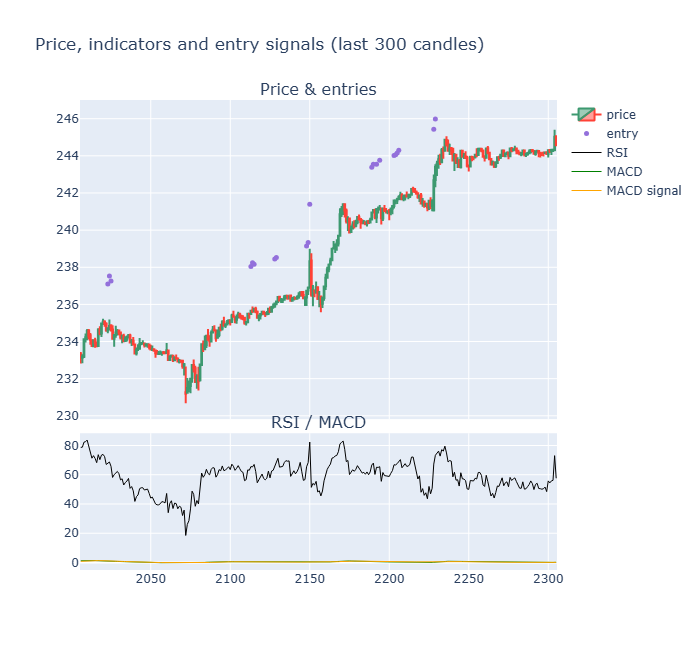

In [16]:
# Displaying the backtest
# RSI/MACD live on a different scale than price, so we use two stacked panels
# instead of overlaying everything on the same axis.

def plot_signals(df, last_n=300):
    df = df.tail(last_n)
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.7, 0.3],
                         vertical_spacing=0.03, subplot_titles=("Price & entries", "RSI / MACD"))

    fig.add_trace(go.Candlestick(x=df.index, open=df['Open'], high=df['High'],
                                  low=df['Low'], close=df['Close'], name="price"), row=1, col=1)
    df_filtered = df[df["pointpos"] != 0]
    fig.add_scatter(x=df_filtered.index, y=df_filtered["pointpos"], mode="markers",
                     marker=dict(size=5, color="MediumPurple"), name="entry", row=1, col=1)

    fig.add_scatter(x=df.index, y=df['RSI'], line=dict(color='black', width=1), name="RSI", row=2, col=1)
    fig.add_scatter(x=df.index, y=df['MACD'], line=dict(color='green', width=1), name="MACD", row=2, col=1)
    fig.add_scatter(x=df.index, y=df['MACD_signal'], line=dict(color='orange', width=1), name="MACD signal", row=2, col=1)

    fig.update_layout(title='Price, indicators and entry signals (last %d candles)' % last_n,
                       xaxis_rangeslider_visible=False, xaxis2_rangeslider_visible=False, height=650)
    fig.show()

plot_signals(df)

In [17]:
### Strategy definition ###

class YourStrat(Strategy):
    initsize = 1
    mysize = initsize
    commission = 0.00
    slcoef = 1.5             # ATR multiplier for the stop loss
    TPSLRatio = 2.0           # take-profit / stop-loss ratio
    def init(self):
        super().init()
        self.signal1 = self.I(SIGNAL)

    def next(self):
        super().next()
        slatr = self.slcoef*self.data.ATR[-1]
        TPSLRatio = self.TPSLRatio

        if self.signal1==2 and len(self.trades)==0:  # entering a long
            sl1 = self.data.Close[-1] - slatr
            tp1 = self.data.Close[-1] + slatr*TPSLRatio
            self.buy(sl=sl1, tp=tp1, size=self.mysize)

        elif self.signal1==1 and len(self.trades)==0:  # entering a short
            sl1 = self.data.Close[-1] + slatr
            tp1 = self.data.Close[-1] - slatr*TPSLRatio
            self.sell(sl=sl1, tp=tp1, size=self.mysize)

- "Margin" is roughly the leverage used:  $margin = \frac{1}{10} \Leftrightarrow leverage = \times10$

In [18]:
### Backtesting the strategy ###

def run_strategy(df, strategy, cash=100, margin=1/50, commission=.00):
    bt = Backtest(df, strategy, cash=cash, margin=margin, commission=commission)
    stat = bt.run()
    print(stat)

run_strategy(df, YourStrat, cash=100, margin=1/10, commission=.00)

Start                                       0
End                                      2305
Duration                                 2305
Exposure Time [%]                    18.38682
Equity Final [$]                    101.67974
Equity Peak [$]                     107.46271
Return [%]                            1.67974
Buy & Hold Return [%]                -0.08783
Return (Ann.) [%]                         0.0
Volatility (Ann.) [%]                      --
Sharpe Ratio                               --
Sortino Ratio                              --
Calmar Ratio                              0.0
Alpha [%]                              1.6765
Beta                                 -0.03696
Max. Drawdown [%]                    -6.71812
Avg. Drawdown [%]                     -2.3706
Max. Drawdown Duration                 1183.0
Avg. Drawdown Duration              287.71429
# Trades                                   30
Win Rate [%]                             30.0
Best Trade [%]                    

C:\Users\theop\AppData\Local\Temp\ipykernel_45164\3124627748.py:4: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(df, strategy, cash=cash, margin=margin, commission=commission)
C:\Users\theop\AppData\Local\Temp\ipykernel_45164\3124627748.py:4: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(df, strategy, cash=cash, margin=margin, commission=commission)


C:\Users\theop\AppData\Local\Temp\ipykernel_45164\941774202.py:3: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(df, strategy, cash=cash, margin=margin, commission=commission)
C:\Users\theop\AppData\Local\Temp\ipykernel_45164\941774202.py:3: UserWarning: Data index is not datetime. Assuming simple periods, but `pd.DateTimeIndex` is advised.
  bt = Backtest(df, strategy, cash=cash, margin=margin, commission=commission)


Best parameters: slcoef=2.8, TPSLRatio=2.8, Return [%]=35.64


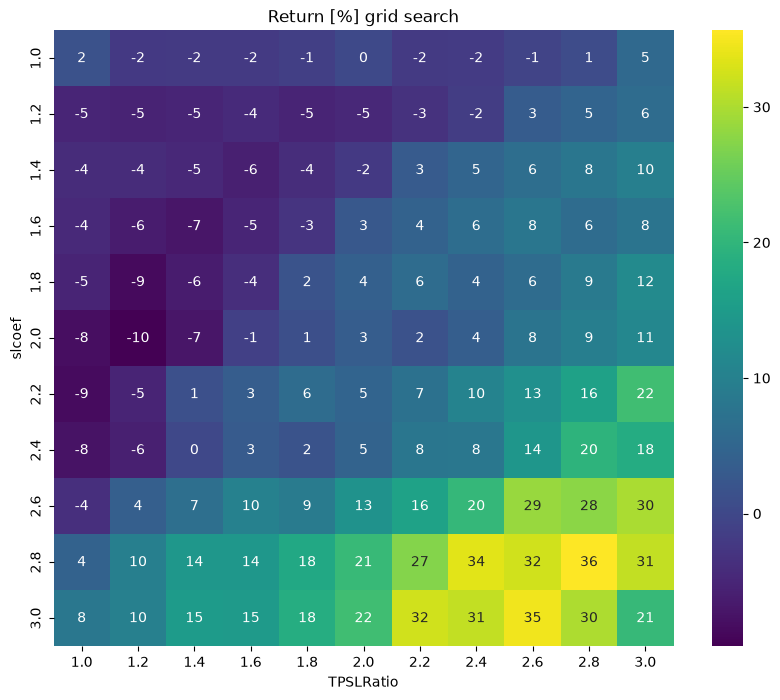

,1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.4,2.6,2.8,3.0
1.0,1.589771,-2.179804,-2.170860,-2.050087,-1.371007,0.228498,-2.118544,-1.898467,-0.640019,0.618430,5.472004
1.2,-5.033364,-5.432534,-5.055587,-4.307998,-5.258241,-4.767595,-3.257457,-1.747318,3.281751,4.639499,5.997248
1.4,-4.159703,-4.220303,-4.767965,-5.754272,-3.968947,-2.183622,3.146033,4.753570,6.361107,7.968644,9.717791
1.6,-4.483542,-6.312210,-7.152160,-5.088495,-3.024830,2.506969,4.367448,6.227926,8.088405,6.012709,7.654389
1.8,-5.360013,-8.600670,-6.265810,-3.930949,1.846648,3.952924,6.059200,4.277938,6.064841,8.831707,11.758768
2.0,-8.115021,-9.805543,-7.252529,-1.231381,1.067650,3.366682,1.559092,3.550085,7.690506,9.425318,11.160129
2.2,-8.532974,-5.353391,1.370522,3.382264,6.170159,4.721591,7.175479,10.450565,12.857792,16.205448,21.621151
2.4,-7.583866,-5.881363,0.098492,3.132131,1.888704,4.525064,8.019925,8.209203,14.011009,19.551660,18.113186
2.6,-3.623850,3.843079,6.541811,10.038739,8.981545,13.126374,16.466518,20.455492,28.656415,27.742762,29.820759
2.8,4.336653,9.599622,14.233454,14.239038,17.517026,20.874643,27.289716,33.666124,32.427112,35.639259,31.424484


In [19]:
### Optimizing the strategy ###
# Reusing the optimize_strategy() helper defined above; tweak the grid to optimize other parameters.

optimize_strategy(
    df, YourStrat,
    {'slcoef': [i/10 for i in range(10, 31, 2)], 'TPSLRatio': [i/10 for i in range(10, 31, 2)]},
    cash=100, margin=1/10, commission=.00,
)

# Going further

- Try to get richer datasets and implement strategies on smaller timeframes.

- Generate signals with a recurrent neural network (maybe in a future workshop).

- Build strategies with more elaborate trade management than a single stop loss / take profit.

- Manage several orders at once and trade multiple assets in the same portfolio.

## A note on overfitting

Every backtest and grid search above is optimized and evaluated on the same price history, with no train/test split. That means the parameters we picked (`slcoef`, `TPSLRatio`, ...) are, to some extent, curve-fit to this specific data. There is no evidence here that they would hold up on data the strategy hasn't seen. A serious setup would split the data into a training window (to search parameters) and a held-out test window (to evaluate them), ideally repeated across several non-overlapping windows (walk-forward validation), before trusting any result.

The leverage (`margin=1/10`) used throughout is likewise chosen only so a $100 backtest can take meaningful positions. It is not a risk-management recommendation.